In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [2]:
df = pd.read_csv("cleaned_global_water_consumption.csv")

df.head()

,Country,Year,Total Water Consumption (Billion Cubic Meters),Per Capita Water Use (Liters per Day),Agricultural Water Use (%),Industrial Water Use (%),Household Water Use (%),Rainfall Impact (Annual Precipitation in mm),Groundwater Depletion Rate (%),Water Scarcity Level
0,Argentina,2000,481.490000,235.431429,48.550000,20.844286,30.100000,1288.698571,3.255714,Moderate
1,Argentina,2001,455.063000,299.551000,48.465000,26.943000,22.550000,1371.729000,3.120000,Moderate
2,Argentina,2002,482.749231,340.124615,50.375385,29.042308,23.349231,1590.305385,2.733846,Moderate
3,Argentina,2003,452.660000,326.756667,49.086667,30.476000,24.440000,1816.012667,2.708000,Moderate
4,Argentina,2004,634.566000,230.346000,38.670000,36.670000,23.924000,815.998000,1.902000,Moderate


In [3]:
print(df.shape)

df.info()

df.describe()

(500, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Country                                         500 non-null    object 
 1   Year                                            500 non-null    int64  
 2   Total Water Consumption (Billion Cubic Meters)  500 non-null    float64
 3   Per Capita Water Use (Liters per Day)           500 non-null    float64
 4   Agricultural Water Use (%)                      500 non-null    float64
 5   Industrial Water Use (%)                        500 non-null    float64
 6   Household Water Use (%)                         500 non-null    float64
 7   Rainfall Impact (Annual Precipitation in mm)    500 non-null    float64
 8   Groundwater Depletion Rate (%)                  500 non-null    float64
 9   Water Scarcity Level             

,Year,Total Water Consumption (Billion Cubic Meters),Per Capita Water Use (Liters per Day),Agricultural Water Use (%),Industrial Water Use (%),Household Water Use (%),Rainfall Impact (Annual Precipitation in mm),Groundwater Depletion Rate (%)
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,2012.000000,501.224430,276.004782,50.180829,27.792837,24.832515,1544.824300,2.573037
std,7.218324,96.078937,42.669593,5.566886,4.361660,2.956135,292.786579,0.480630
min,2000.000000,129.636667,111.708333,28.905000,13.276667,13.668333,700.230000,1.300000
25%,2006.000000,441.447385,250.225406,46.513611,25.018000,23.015355,1353.734583,2.235000
50%,2012.000000,502.197154,276.430556,50.318482,27.648539,25.071944,1537.537724,2.555778
75%,2018.000000,563.849594,300.221750,54.061964,30.698333,26.720167,1746.402425,2.887202
max,2024.000000,798.418000,404.350000,66.520000,43.583333,34.202000,2533.678000,4.322000


In [4]:
df.isnull().sum()

Country                                           0
Year                                              0
Total Water Consumption (Billion Cubic Meters)    0
Per Capita Water Use (Liters per Day)             0
Agricultural Water Use (%)                        0
Industrial Water Use (%)                          0
Household Water Use (%)                           0
Rainfall Impact (Annual Precipitation in mm)      0
Groundwater Depletion Rate (%)                    0
Water Scarcity Level                              0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.drop_duplicates(inplace=True)

In [7]:
le = LabelEncoder()

df["Country"] = le.fit_transform(df["Country"])

df["Water Scarcity Level"] = le.fit_transform(df["Water Scarcity Level"])

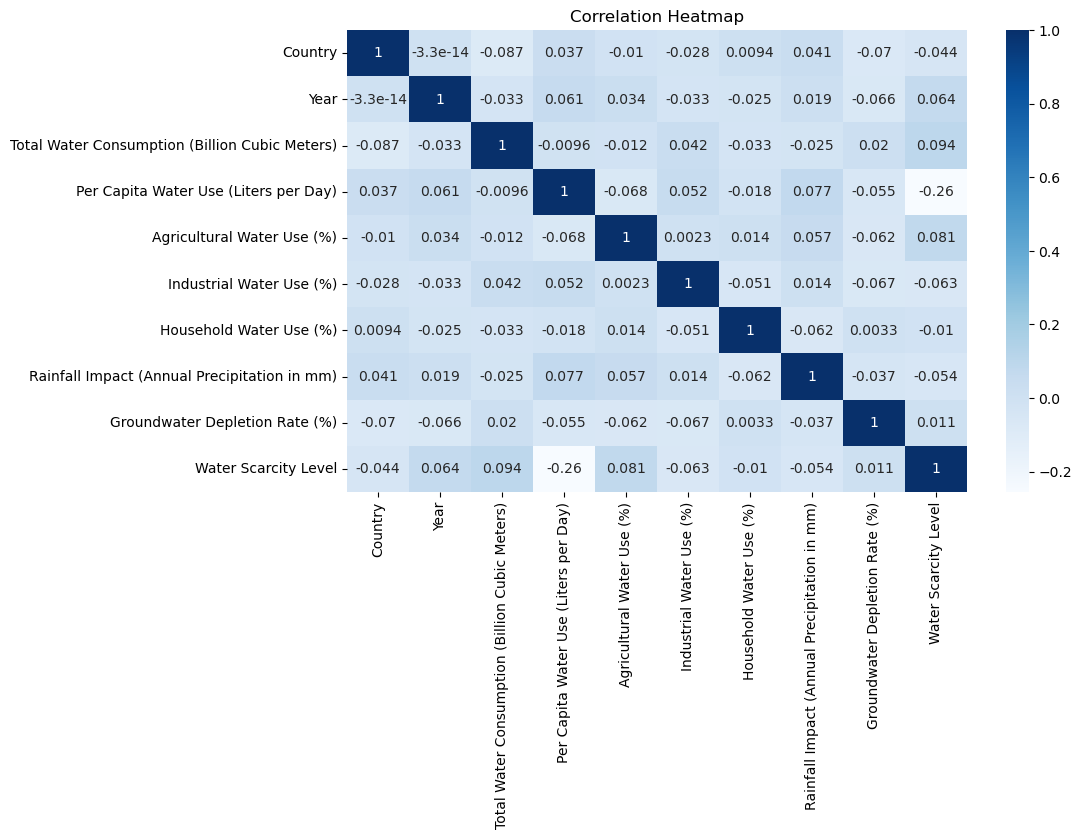

In [8]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Heatmap")
plt.show()

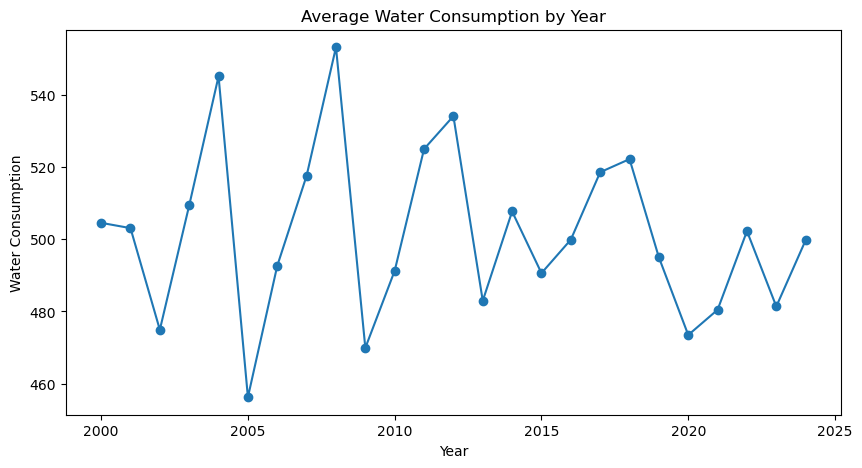

In [11]:
plt.figure(figsize=(10,5))

yearly_consumption = df.groupby('Year')['Total Water Consumption (Billion Cubic Meters)'].mean()

plt.plot(yearly_consumption.index,
         yearly_consumption.values,
         marker='o')

plt.title('Average Water Consumption by Year')
plt.xlabel('Year')
plt.ylabel('Water Consumption')

plt.show()

In [10]:
X = df.drop(
    "Total Water Consumption (Billion Cubic Meters)",
    axis=1
)

y = df["Total Water Consumption (Billion Cubic Meters)"]

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(400, 9)
(100, 9)


In [13]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [14]:
predictions = model.predict(X_test)

predictions[:5]

array([491.81002591, 485.40812211, 502.72706892, 519.18058256,
       511.77179816])

In [15]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_test, predictions)

mse = mean_squared_error(y_test, predictions)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, predictions)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 75.45641133135587
MSE : 9570.254006387091
RMSE : 97.82767505357107
R2 Score : -0.0020744427865992954


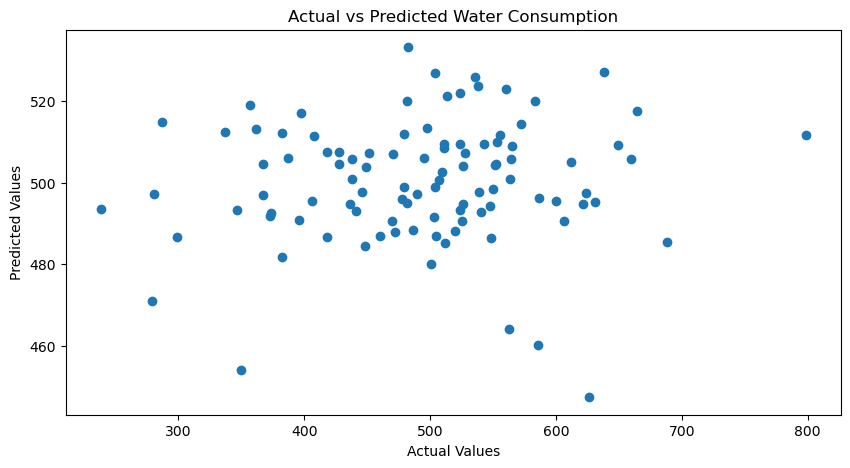

In [16]:
plt.figure(figsize=(10,5))

plt.scatter(y_test,
            predictions)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted Water Consumption")

plt.show()

In [17]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [18]:
rf_predictions = rf.predict(X_test)

rf_predictions[:5]

array([452.6265823 , 491.82597803, 534.61991783, 513.68226478,
       505.38574029])

In [19]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

mae_rf = mean_absolute_error(y_test, rf_predictions)

mse_rf = mean_squared_error(y_test, rf_predictions)

rmse_rf = np.sqrt(mse_rf)

r2_rf = r2_score(y_test, rf_predictions)

print("MAE :", mae_rf)
print("RMSE :", rmse_rf)
print("R2 Score :", r2_rf)

MAE : 77.52276302174997
RMSE : 101.76541608759007
R2 Score : -0.08436863313735721


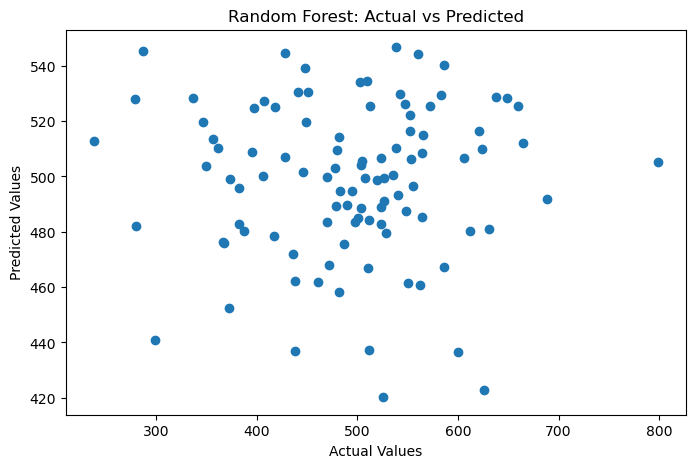

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(y_test, rf_predictions)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Random Forest: Actual vs Predicted")

plt.show()

               Model        MAE        RMSE  R2 Score
0  Linear Regression  75.456411   97.827675 -0.002074
1      Random Forest  77.522763  101.765416 -0.084369
2  Gradient Boosting  80.689418  106.886232 -0.196245

Random Forest CV R2 mean: -0.0806


C:\Users\venka\AppData\Local\Temp\ipykernel_18752\63439462.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances.values, y=feature_importances.index, palette="viridis")


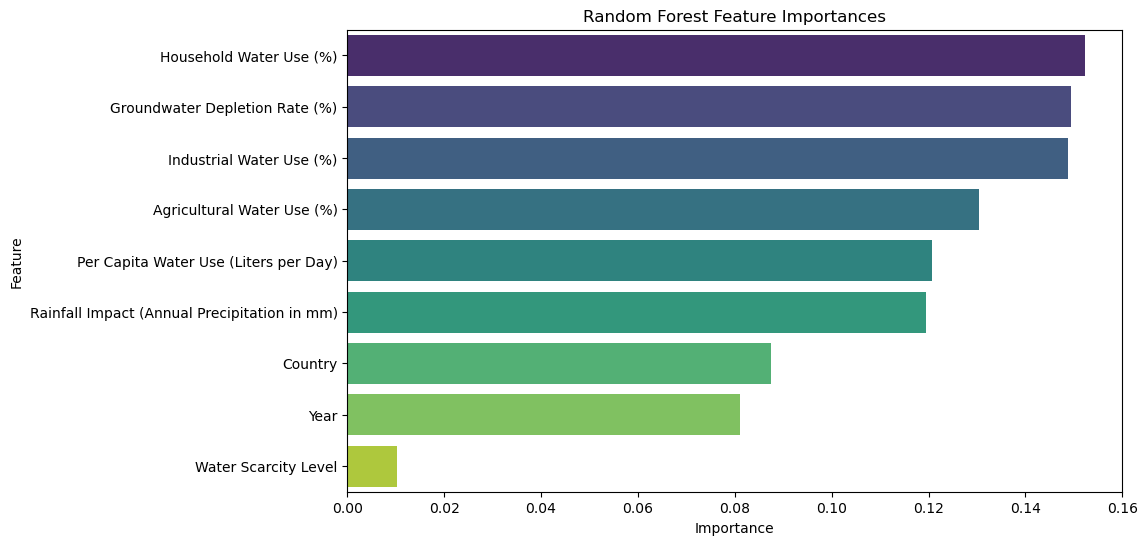

In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score

# Scale numerical features for regression models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train stronger regression models
lr_scaled = LinearRegression()
lr_scaled.fit(X_train_scaled, y_train)

gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)
gbr.fit(X_train_scaled, y_train)

# Compare model performance
comparison = []
for name, model_obj, X_eval in [
    ("Linear Regression", lr_scaled, X_test_scaled),
    ("Random Forest", rf, X_test),
    ("Gradient Boosting", gbr, X_test_scaled)
]:
    preds = model_obj.predict(X_eval)
    mae_val = mean_absolute_error(y_test, preds)
    rmse_val = np.sqrt(mean_squared_error(y_test, preds))
    r2_val = r2_score(y_test, preds)
    comparison.append({
        "Model": name,
        "MAE": mae_val,
        "RMSE": rmse_val,
        "R2 Score": r2_val
    })

comparison_df = pd.DataFrame(comparison).sort_values(by="RMSE")
print(comparison_df)

# Cross-validation for the Random Forest model
cv_scores = cross_val_score(rf, X, y, cv=5, scoring="r2")
print("\nRandom Forest CV R2 mean:", np.mean(cv_scores).round(4))

# Feature importance from Random Forest
feature_importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette="viridis")
plt.title("Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [22]:
import pickle

with open("linear_regression_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully!")

Model saved successfully!


In [23]:
import pickle

with open("linear_regression_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

print("Model loaded successfully!")

Model loaded successfully!


In [24]:
sample_prediction = loaded_model.predict(X_test[:5])

print(sample_prediction)

[491.81002591 485.40812211 502.72706892 519.18058256 511.77179816]
